In [5]:
pip install gymnasium


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
pip install pygame

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


: 

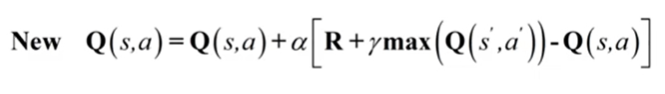

CartPole-v0
CartPole-v1
MountainCar-v0
MountainCarContinuous-v0
Pendulum-v1
Acrobot-v1
phys2d/CartPole-v0
phys2d/CartPole-v1
phys2d/Pendulum-v0
LunarLander-v3
LunarLanderContinuous-v3
BipedalWalker-v3
BipedalWalkerHardcore-v3
CarRacing-v3
Blackjack-v1
FrozenLake-v1
FrozenLake8x8-v1
CliffWalking-v0
Taxi-v3
tabular/Blackjack-v0
tabular/CliffWalking-v0
Reacher-v2
Reacher-v4
Reacher-v5
Pusher-v2
Pusher-v4
Pusher-v5
InvertedPendulum-v2
InvertedPendulum-v4
InvertedPendulum-v5
InvertedDoublePendulum-v2
InvertedDoublePendulum-v4
InvertedDoublePendulum-v5
HalfCheetah-v2
HalfCheetah-v3
HalfCheetah-v4
HalfCheetah-v5
Hopper-v2
Hopper-v3
Hopper-v4
Hopper-v5
Swimmer-v2
Swimmer-v3
Swimmer-v4
Swimmer-v5
Walker2d-v2
Walker2d-v3
Walker2d-v4
Walker2d-v5
Ant-v2
Ant-v3
Ant-v4
Ant-v5
Humanoid-v2
Humanoid-v3
Humanoid-v4
Humanoid-v5
HumanoidStandup-v2
HumanoidStandup-v4
HumanoidStandup-v5
GymV21Environment-v0
GymV26Environment-v0
Episode: 1
Episode: 2
Episode: 3
Episode: 4
Episode: 5
Episode: 6
Episode: 7
Epi

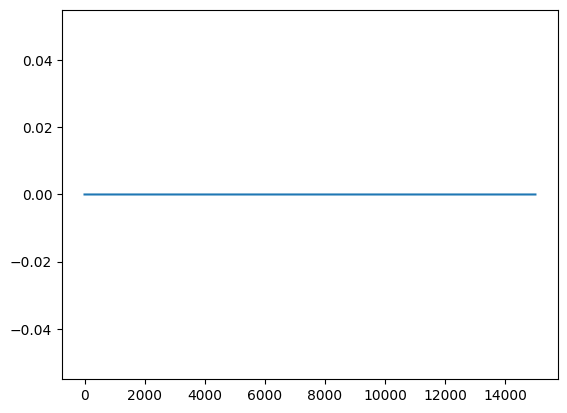

In [1]:
import gymnasium as gym
import numpy as np
import random
import time
#from IPython.display import clear_output
import matplotlib.pyplot as plt
from gymnasium.envs.toy_text.frozen_lake import generate_random_map

def validar_entornos():
    import gymnasium as gym
    for i in gym.envs.registry.keys():
	    print(i)

validar_entornos()

class GamesNames:
    def __init__(self):
      self.taxi = 'Taxi-v3'
      self.laguna = 'FrozenLake-v1'


def train(episodios):

  juegos = GamesNames()


  env = gym.make(juegos.taxi)
  q_table = np.zeros((env.observation_space.n, env.action_space.n))

  learning_rate= 0.1
  discount_factor = 0.95
  epsilon = 1
  epsilon_decay_rate = 0.0001
  rng = np.random.default_rng()

  rewards_per_episode = np.zeros(episodios)

  for i in range(episodios):


    if (i+1)%1000==0 :
      env.close()
      env = gym.make(juegos.taxi,render_mode="human")
    else:
      env.close()
      env = gym.make(juegos.taxi)

    print(f"Episode: {i+1}")
    terminated = False
    truncated = False
    state = env.reset()[0]

    while (not terminated and not truncated):
      # decision acción
      if rng.random() < epsilon:
        action = env.action_space.sample() # exploración
      else:
        action = np.argmax(q_table[state,:]) # explotación mejor acciónb basada en Q_table

      # tomar acción
      new_state, reward, terminated, truncated, info = env.step(action)

      q_table[state,action] =\
         q_table[state,action] + learning_rate *\
          (reward + discount_factor * np.max(q_table[new_state,:]) - q_table[state,action])

      state = new_state

    epsilon= max(epsilon-epsilon_decay_rate,0)

    if reward == 1:
       rewards_per_episode[i] = 1

    if (i+1) %100==0:
       print(f"Episodio:{i+1} -recompensa :{rewards_per_episode[i]}")


  env.close()

  print(f"mejor Q_table: \n {q_table}")

  sum_rewards =np.zeros(episodios)
  for t in range(episodios):
    sum_rewards[t] =np.sum(rewards_per_episode[max(0,t-100):t+1])

  plt.plot(sum_rewards)
  plt.show()

train(15000)


In [ ]:
import gymnasium as gym
import numpy as np
import random
import time
#from IPython.display import clear_output
import matplotlib.pyplot as plt
from gymnasium.envs.toy_text.frozen_lake import generate_random_map

def validar_entornos():
    import gymnasium as gym
    for i in gym.envs.registry.keys():
	    print(i)

validar_entornos()

def train(episodios):
  # env_name = 'Taxi-v3'
  env_name = 'FrozenLake-v1'

  env = gym.make(env_name)
  q_table = np.zeros((env.observation_space.n, env.action_space.n))

  learning_rate= 0.1
  discount_factor = 0.95
  epsilon = 1
  epsilon_decay_rate = 0.0001
  rng = np.random.default_rng()

  rewards_per_episode = np.zeros(episodios)

  for i in range(episodios):


    if (i+1)%1000==0 :
      env.close()
      env = gym.make("FrozenLake-v1",render_mode="human")
    else:
      env.close()
      env = gym.make("FrozenLake-v1")



    print(f"Episode: {i+1}")
    terminated = False
    truncated = False
    state = env.reset()[0]

    while (not terminated and not truncated):
      # decision acción
      if rng.random() < epsilon:
        action = env.action_space.sample() # exploración
      else:
        action = np.argmax(q_table[state,:]) # explotación mejor acciónb basada en Q_table

      # tomar acción
      new_state, reward, terminated, truncated, info = env.step(action)

      q_table[state,action] = q_table[state,action] + learning_rate*(reward +
                                                                      discount_factor*np.max(q_table[new_state,:]) - q_table[state,action])

      state = new_state

    epsilon= max(epsilon-epsilon_decay_rate,0)

    if reward == 1:
       rewards_per_episode[i] = 1

    if (i+1) %100==0:
       print(f"Episodio:{i+1} -recompensa :{rewards_per_episode[i]}")


  env.close()

  print(f"mejor Q_table: \n {q_table}")

  sum_rewards =np.zeros(episodios)
  for t in range(episodios):
    sum_rewards[t] =np.sum(rewards_per_episode[max(0,t-100):t+1])

  plt.plot(sum_rewards)
  plt.show()

train(15000)


CartPole-v0
CartPole-v1
MountainCar-v0
MountainCarContinuous-v0
Pendulum-v1
Acrobot-v1
phys2d/CartPole-v0
phys2d/CartPole-v1
phys2d/Pendulum-v0
LunarLander-v3
LunarLanderContinuous-v3
BipedalWalker-v3
BipedalWalkerHardcore-v3
CarRacing-v3
Blackjack-v1
FrozenLake-v1
FrozenLake8x8-v1
CliffWalking-v0
Taxi-v3
tabular/Blackjack-v0
tabular/CliffWalking-v0
Reacher-v2
Reacher-v4
Reacher-v5
Pusher-v2
Pusher-v4
Pusher-v5
InvertedPendulum-v2
InvertedPendulum-v4
InvertedPendulum-v5
InvertedDoublePendulum-v2
InvertedDoublePendulum-v4
InvertedDoublePendulum-v5
HalfCheetah-v2
HalfCheetah-v3
HalfCheetah-v4
HalfCheetah-v5
Hopper-v2
Hopper-v3
Hopper-v4
Hopper-v5
Swimmer-v2
Swimmer-v3
Swimmer-v4
Swimmer-v5
Walker2d-v2
Walker2d-v3
Walker2d-v4
Walker2d-v5
Ant-v2
Ant-v3
Ant-v4
Ant-v5
Humanoid-v2
Humanoid-v3
Humanoid-v4
Humanoid-v5
HumanoidStandup-v2
HumanoidStandup-v4
HumanoidStandup-v5
GymV21Environment-v0
GymV26Environment-v0


TypeError: make() missing 1 required positional argument: 'id'

Episode: 1
Episode: 2
Episode: 3
Episode: 4
Episode: 5
Episode: 6
Episode: 7
Episode: 8
Episode: 9
Episode: 10
Episode: 11
Episode: 12
Episode: 13
Episode: 14
Episode: 15
Episode: 16
Episode: 17
Episode: 18
Episode: 19
Episode: 20
Episode: 21
Episode: 22
Episode: 23
Episode: 24
Episode: 25
Episode: 26
Episode: 27
Episode: 28
Episode: 29
Episode: 30
Episode: 31
Episode: 32
Episode: 33
Episode: 34
Episode: 35
Episode: 36
Episode: 37
Episode: 38
Episode: 39
Episode: 40
Episode: 41
Episode: 42
Episode: 43
Episode: 44
Episode: 45
Episode: 46
Episode: 47
Episode: 48
Episode: 49
Episode: 50
Episode: 51
Episode: 52
Episode: 53
Episode: 54
Episode: 55
Episode: 56
Episode: 57
Episode: 58
Episode: 59
Episode: 60
Episode: 61
Episode: 62
Episode: 63
Episode: 64
Episode: 65
Episode: 66
Episode: 67
Episode: 68
Episode: 69
Episode: 70
Episode: 71
Episode: 72
Episode: 73
Episode: 74
Episode: 75
Episode: 76
Episode: 77
Episode: 78
Episode: 79
Episode: 80
Episode: 81
Episode: 82
Episode: 83
Episode: 84
E

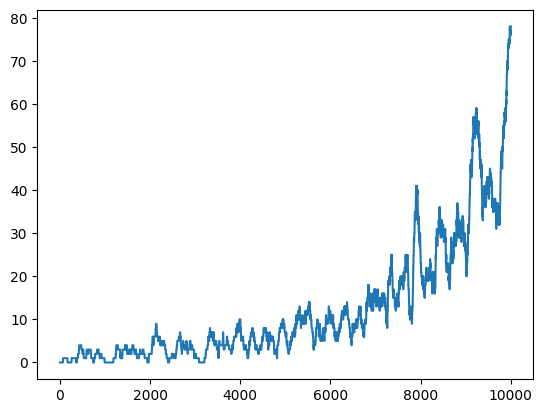

In [4]:
train(10000)